In [11]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import os
import pandas as pd
import matplotlib as mpl
import cmocean
import glob

In [2]:
os.chdir('/Users/gawasi001/Documents/Paper_msc/Data_uofm/')

data = xr.open_dataset('ANHA4_mesh_zgr.nc')
dx = data.variables['e1t']
dy = data.variables['e2t']
e3t = data.variables['e3t_0']
lon = data.variables['nav_lon']
lat = data.variables['nav_lat'] 
bat = data.variables['hdept']
bat = bat[0]

In [50]:
os.chdir('/Users/gawasi001/Documents/Paper_msc/Data_uofm/Figures3&SI2_Melt_Mass_Rate/berg_floating_melt')

files_vs = sorted(glob.glob("ANHA4-EJM010-S_*_berg_floating_melt.npz"))

vs = []
for file in files_vs:
    data = np.load(file)
    vs.append(data["berg_floating_melt"])

vs = np.concatenate(vs, axis=0)

files_vd = sorted(glob.glob("ANHA4-EJM012-S_*_berg_floating_melt.npz"))

vd = []
for file in files_vd:
    data = np.load(file)
    vd.append(data["berg_floating_melt"])

vd = np.concatenate(vd, axis=0)

print("VS shape:", vs.shape)
print("VD shape:", vd.shape)

VS shape: (1168, 800, 544)
VD shape: (1168, 800, 544)


In [20]:
vs[np.where(vs == 0 )] = np.nan

vd[np.where(vd == 0 )] = np.nan

### Average melt rates

In [21]:
avg_vs = np.zeros(1168)
avg_vd = np.zeros(1168)

for day in range(0, len(vs)):
    avg_vs[day] = np.nanmean(vs[day])
    avg_vd[day] = np.nanmean(vd[day])

/var/folders/h3/s4smkhd56ks24x42jbqd3gcc0g4l6k/T/ipykernel_12353/1213572763.py:5: RuntimeWarning: Mean of empty slice
  avg_vs[day] = np.nanmean(vs[day])
/var/folders/h3/s4smkhd56ks24x42jbqd3gcc0g4l6k/T/ipykernel_12353/1213572763.py:6: RuntimeWarning: Mean of empty slice
  avg_vd[day] = np.nanmean(vd[day])


In [22]:
dif_avg_vdvs = avg_vd - avg_vs

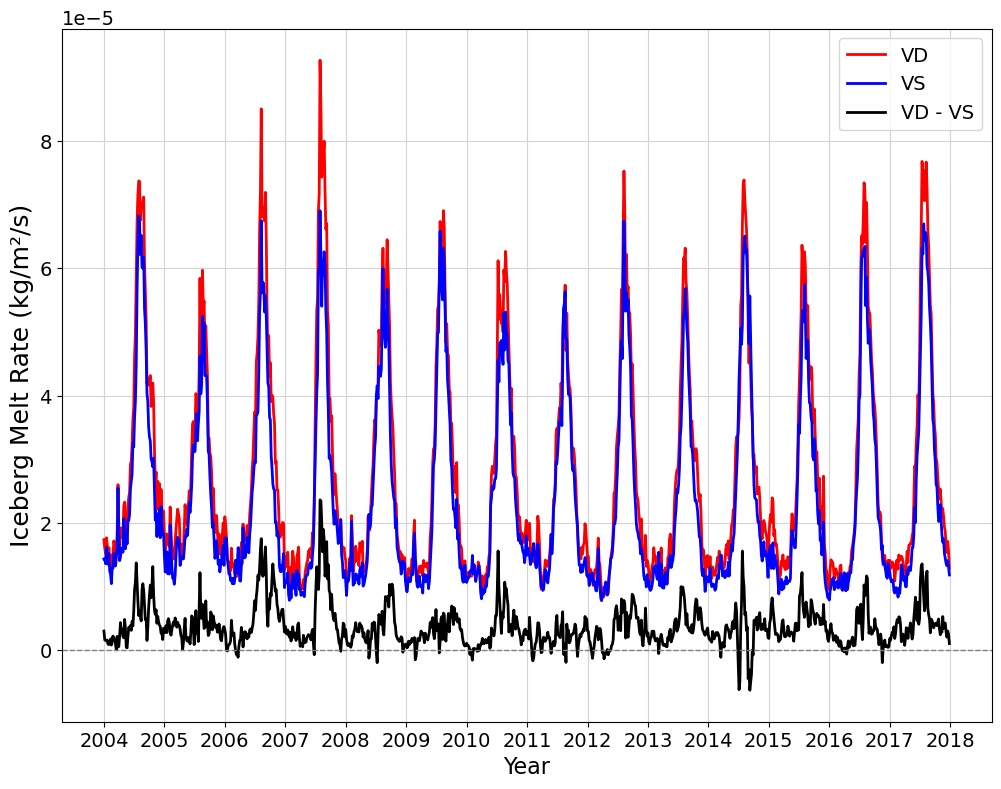

In [37]:
fig, ax =  plt.subplots(nrows =1, ncols = 1, figsize = (12, 9))

d = ax.plot(avg_vd[146:], color = 'red', linewidth=2)
b = ax.plot(avg_vs[146:], color = 'blue', linewidth=2)
ax.plot(dif_avg_vdvs[146:], color='black', linewidth=2, linestyle = '-')

ax.set_ylabel('Iceberg Melt Rate (kg/m\u00b2/s)', fontsize = 18)
ax.set_xlabel('Year', fontsize = 16)

ax.legend([
          'VD',
          'VS', 'VD - VS'], fontsize=14, handlelength=2)

ax.set_xticks(np.arange(0, 1168-73, 73))
ax.set_xticklabels(np.arange(2004, 2019))
ax.grid(color='lightgray')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.yaxis.offsetText.set_fontsize(14)
ax.axhline(y=0, color='grey', linestyle='--', linewidth=1)
ax.grid(color = 'lightgray')


plt.savefig('/Users/gawasi001/Documents/Paper_msc/Data_uofm/Figures3&SI2_Melt_Mass_Rate/Average_melt_rates', 
            dpi=300, bbox_inches='tight')

### Time series accumulated melt mass

In [28]:
area = (dx * dy).values
area = area[0]

print(area.shape)

(800, 544)


In [38]:
dt = 86400*5

vs_daily_mass = np.nansum(vs * area[None, :, :], axis=(1, 2)) * dt
vd_daily_mass = np.nansum(vd * area[None, :, :], axis=(1, 2)) * dt

vs_accum_mass = np.cumsum(vs_daily_mass)
vd_accum_mass = np.cumsum(vd_daily_mass)

print(vs_accum_mass.shape)
print(vd_accum_mass.shape)

(1168,)
(1168,)


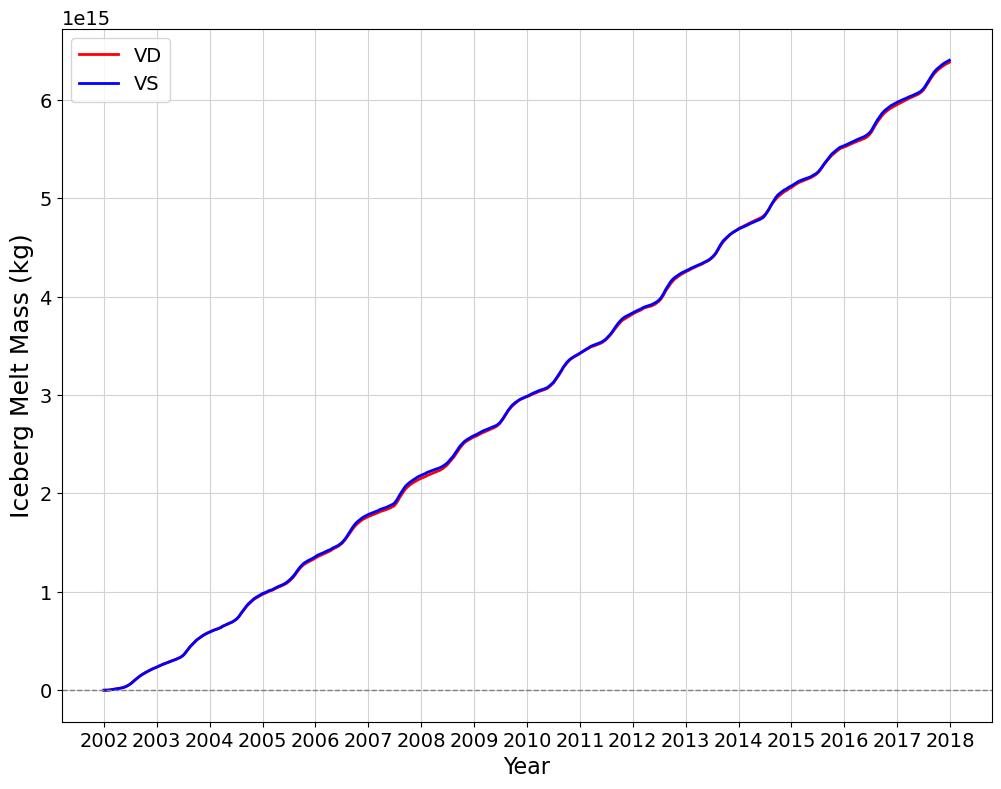

In [39]:
fig, ax =  plt.subplots(nrows =1, ncols = 1, figsize = (12, 9))

d = ax.plot(vd_accum_mass, color = 'red', linewidth=2)
b = ax.plot(vs_accum_mass, color = 'blue', linewidth=2)

ax.set_ylabel('Iceberg Melt Mass (kg)', fontsize = 18)
ax.set_xlabel('Year', fontsize = 16)

ax.legend(['VD', 'VS'], fontsize=14, handlelength=2)

ax.set_xticks(np.arange(0, 1168+73, 73))
ax.set_xticklabels(np.arange(2002, 2019))
ax.grid(color='lightgray')
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.yaxis.offsetText.set_fontsize(14)
ax.axhline(y=0, color='grey', linestyle='--', linewidth=1)
ax.grid(color = 'lightgray')

plt.savefig('/Users/gawasi001/Documents/Paper_msc/Data_uofm/Figures3&SI2_Melt_Mass_Rate/Accumulated_melt_mass', 
            dpi=300, bbox_inches='tight')

### Accumulated melt mass map

In [64]:
vs = np.copy(vs)
vs[vs == 0] = np.nan

vs_mass = np.empty((len(vs), 800, 544))

for day in range(len(vs)):
    vs_mass[day] = vs[day] * area * (5 * 86400)

slice_vs = vs_mass[146:]

vs_accum_mass = np.nansum(slice_vs, axis=0)   

In [68]:
vd = np.copy(vd)
vd[vd == 0] = np.nan

vd_mass = np.empty((len(vd), 800, 544))

for day in range(len(vd)):
    vd_mass[day] = vd[day] * area * (5 * 86400)

slice_vd = vd_mass[146:]

vd_accum_mass = np.nansum(slice_vd, axis=0)

In [71]:
vs_accum_mass[np.where(vs_accum_mass == 0)] = np.nan

vd_accum_mass[np.where(vd_accum_mass == 0)] = np.nan

dif_accum = vd_accum_mass - vs_accum_mass

Locator attempting to generate 4286 ticks ([0.0, ..., 85700000000000.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 4150 ticks ([0.0, ..., 165960000000000.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 4717 ticks ([-14040000000000.0, ..., 80280000000000.0]), which exceeds Locator.MAXTICKS (1000).


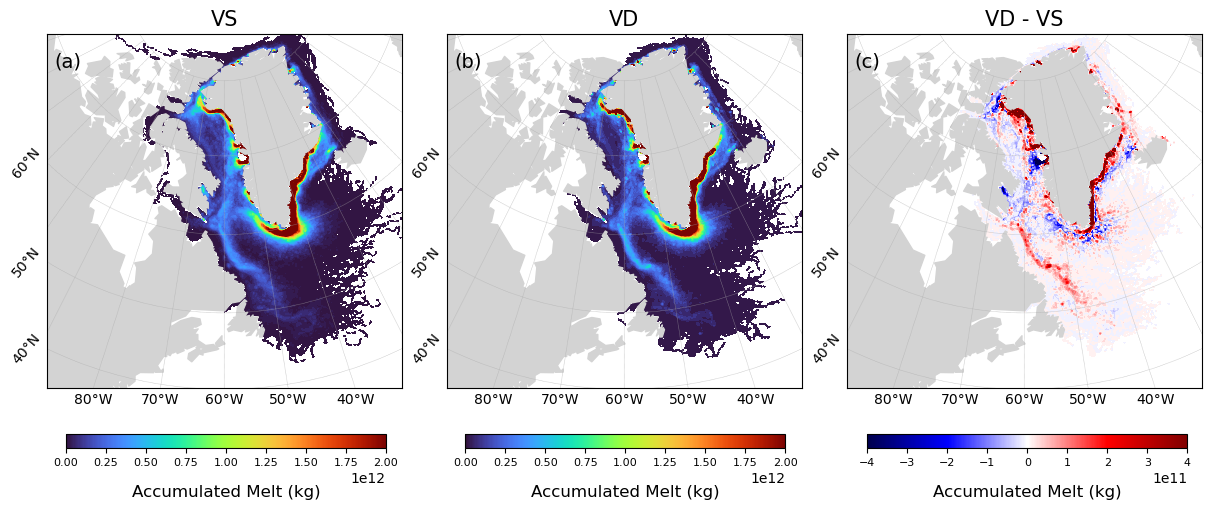

In [72]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.basemap import Basemap
import numpy as np

# Set up figure and axes
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4), constrained_layout=True)

# Define variable-specific settings
variables = [vs_accum_mass, vd_accum_mass, dif_accum]
titles = ['VS', 'VD', 'VD - VS']
vmins = [1, 1, -400000000000]
vmaxs = [ 2000000000000,2000000000000, 400000000000]
labels = ['Accumulated Melt (kg)',
          'Accumulated Melt (kg)',
          'Accumulated Melt (kg)']

cmaps = [plt.get_cmap('turbo'),plt.get_cmap('turbo'), plt.get_cmap('seismic')]

for col, (var, vmin, vmax, label, title, cmp) in enumerate(zip(variables, vmins, vmaxs, labels, titles, cmaps)):
    levels = 5000
    lv = (vmax - vmin) / levels
    level_list = list(np.arange(vmin, vmax + lv, lv))
    

    # Plot
    ax = axes[col]
    ax.set_title(title, fontsize=15)
    m = Basemap(projection='aea', resolution='c', width=5E6, height=5E6,
                lat_0=63, lon_0=-60, ax=ax)
    m.contourf(lon, lat, var, latlon=True, levels=levels,
               vmin=vmin, vmax=vmax, cmap=cmp)
         
    m.drawcoastlines(color='lightgray')
    m.fillcontinents(color='lightgray', lake_color='lightgray')
    m.drawmeridians(np.arange(0, 360, 10), labels=[0, 0, 0, 1],
                    linewidth=0.4, color='darkgray', fontsize=10)
    m.drawparallels(np.arange(-90, 90, 10), labels=[1, 0, 0, 0],
                    linewidth=0.4, color='darkgray', fontsize=10, rotation=50)

    # Colorbar (horizontal)
    cbar_x = [0.05, 0.383, 0.718]  # Adjust horizontal position for each colorbar
    cbar_width = 0.8 / 3  # Adjust colorbar width to fit under each map
    cbar_height = 0.035  # Colorbar height for horizontal orientation
    cbar_y = -0.10  # Position the colorbar below each plot

    cax = fig.add_axes([cbar_x[col], cbar_y, cbar_width, cbar_height])
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cb1 = mpl.colorbar.ColorbarBase(cax, cmap=cmp, norm=norm, orientation='horizontal')
    cb1.ax.set_xlabel(label, fontsize=12, labelpad=12)
    cb1.ax.ticklabel_format(style='sci', scilimits=(-1, 4), axis='both')
    cb1.ax.tick_params(labelsize=8) 

labels = ['a', 'b', 'c']
    
for i, ax in enumerate(axes):
    # Add corner label in the upper-left corner of each subplot
    ax.text(0.02, 0.95, f'({labels[i]})', transform=ax.transAxes,
            fontsize=14, va='top', ha='left')


# Save the figure
plt.savefig('/Users/gawasi001/Documents/Paper_msc/Data_uofm/Figures3&SI2_Melt_Mass_Rate/Accumulated_melt_mass_map', bbox_inches='tight')

plt.show()